Extrapolation and Stock Price

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#from mpl_toolkits.mlot3d import Axes3D
import mpl_toolkits.mplot3d
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error,r2_score

In [2]:
N=1000
X=np.random.random((N,2))*6 -3
Y=np.cos(2*X[:,0])+ np.cos(3*X[:,1])

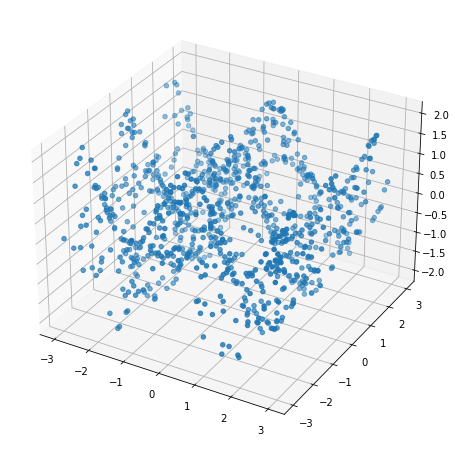

In [3]:
fig= plt.figure(figsize=(20,8))
ax=fig.add_subplot(111,projection='3d')
ax.scatter(X[:,0],X[:,1],Y);

In [4]:
#SVR
model=SVR()
model.fit(X,Y)

SVR()

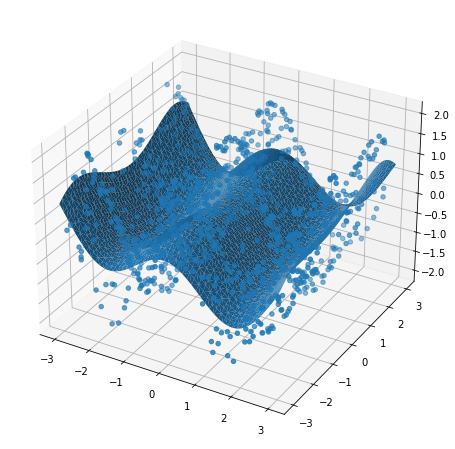

In [5]:
fig= plt.figure(figsize=(20,8))
ax=fig.add_subplot(111,projection='3d')
ax.scatter(X[:,0],X[:,1],Y)

line=np.linspace(-3,3,50)
xx,yy=np.meshgrid(line,line)
Xgrid=np.vstack ((xx.flatten(),yy.flatten())).T 
Yhat=model.predict(Xgrid).flatten()
ax.plot_trisurf(Xgrid[:,0],Xgrid [:,1],Yhat,linewidth=.2,antialiased=True)

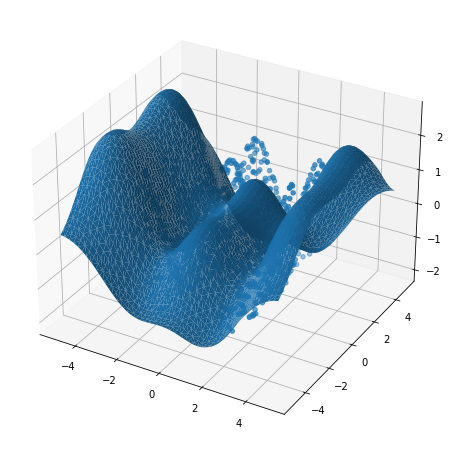

In [12]:
fig=plt.figure(figsize=(20,8))
ax=fig.add_subplot(111,projection='3d')
ax.scatter(X[:,0],X[:,1],Y)

line=np.linspace(-5,5,50)
xx,yy=np.meshgrid(line,line)
Xgrid=np.vstack ((xx.flatten(),yy.flatten())).T 
Yhat=model.predict(Xgrid).flatten()
ax.plot_trisurf(Xgrid[:,0],Xgrid [:,1],Yhat,linewidth=.2,antialiased=True)

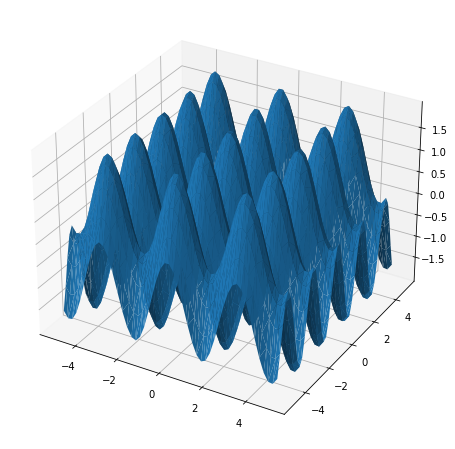

In [13]:
fig=plt.figure(figsize=(20,8))
ax=fig.add_subplot(111,projection='3d')
#ax.scatter(X[:,0],X[:,1],Y)

line=np.linspace(-5,5,50)
xx,yy=np.meshgrid(line,line)
Xgrid=np.vstack ((xx.flatten(),yy.flatten())).T 
Ytrue=np.cos(2*Xgrid[:,0])+ np.cos(3*Xgrid[:,1])
ax.plot_trisurf(Xgrid[:,0],Xgrid [:,1],Ytrue,linewidth=.2,antialiased=True)
plt.show()

In [14]:
model=RandomForestRegressor()
model.fit(X,Y)

RandomForestRegressor()

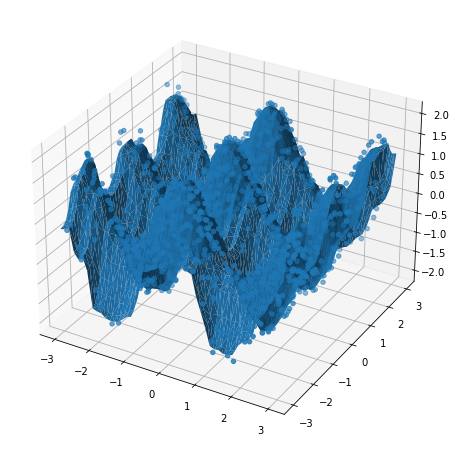

In [15]:
fig= plt.figure(figsize=(20,8))
ax=fig.add_subplot(111,projection='3d')
ax.scatter(X[:,0],X[:,1],Y)

line=np.linspace(-3,3,50)
xx,yy=np.meshgrid(line,line)
Xgrid=np.vstack ((xx.flatten(),yy.flatten())).T 
Yhat=model.predict(Xgrid).flatten()
ax.plot_trisurf(Xgrid[:,0],Xgrid [:,1],Yhat,linewidth=.2,antialiased=True)

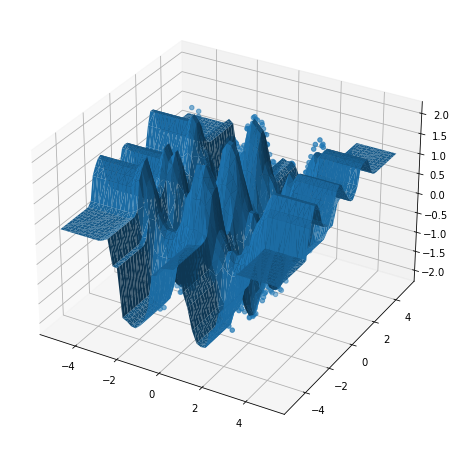

In [16]:
fig= plt.figure(figsize=(20,8))
ax=fig.add_subplot(111,projection='3d')
ax.scatter(X[:,0],X[:,1],Y)

line=np.linspace(-5,5,50)
xx,yy=np.meshgrid(line,line)
Xgrid=np.vstack ((xx.flatten(),yy.flatten())).T 
Yhat=model.predict(Xgrid).flatten()
ax.plot_trisurf(Xgrid[:,0],Xgrid [:,1],Yhat,linewidth=.2,antialiased=True)

In [17]:
model=MLPRegressor(hidden_layer_sizes=128,alpha=0,learning_rate_init=.01)
model.fit(X,Y)

MLPRegressor(alpha=0, hidden_layer_sizes=128, learning_rate_init=0.01)

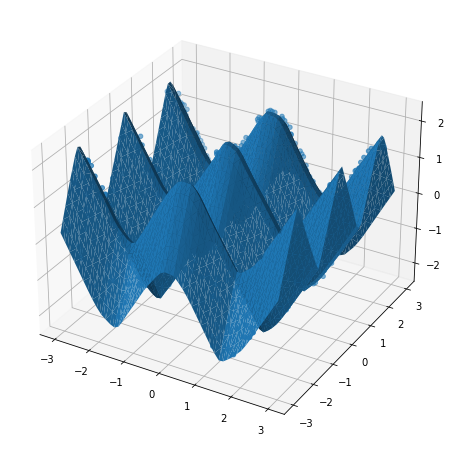

In [18]:
fig= plt.figure(figsize=(20,8))
ax=fig.add_subplot(111,projection='3d')
ax.scatter(X[:,0],X[:,1],Y)

line=np.linspace(-3,3,50)
xx,yy=np.meshgrid(line,line)
Xgrid=np.vstack ((xx.flatten(),yy.flatten())).T 
Yhat=model.predict(Xgrid).flatten()
ax.plot_trisurf(Xgrid[:,0],Xgrid [:,1],Yhat,linewidth=.2,antialiased=True)

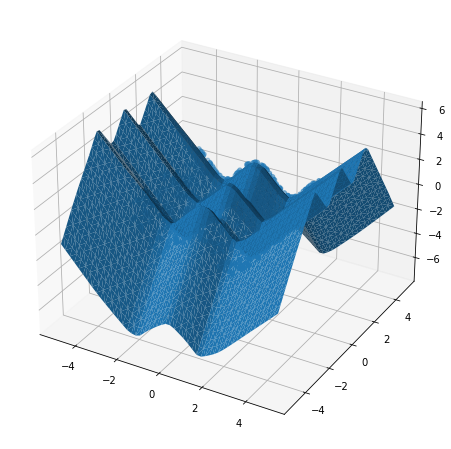

In [19]:
fig= plt.figure(figsize=(20,8))
ax=fig.add_subplot(111,projection='3d')
ax.scatter(X[:,0],X[:,1],Y)

line=np.linspace(-5,5,50)
xx,yy=np.meshgrid(line,line)
Xgrid=np.vstack ((xx.flatten(),yy.flatten())).T 
Yhat=model.predict(Xgrid).flatten()
ax.plot_trisurf(Xgrid[:,0],Xgrid [:,1],Yhat,linewidth=.2,antialiased=True)

Stock Prices

In [20]:
import pandas as pd

In [21]:
df=pd.read_csv('SPY.csv',index_col='Date',parse_dates=True)

In [22]:
df.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2010-01-04,112.370003,113.389999,111.510002,113.330002,92.246048,118944600
2010-01-05,113.260002,113.680000,112.849998,113.629997,92.490204,111579900
2010-01-06,113.519997,113.989998,113.430000,113.709999,92.555328,116074400
2010-01-07,113.500000,114.330002,113.180000,114.190002,92.946060,131091100
2010-01-08,113.889999,114.620003,113.660004,114.570000,93.255348,126402800


In [23]:
train=df.iloc[:2000]['Close'].to_numpy()
test=df.iloc[2000:]['Close'].to_numpy()

In [24]:
Xtrain=[]
for t in range(len(train)-1):
    x0=train[t]
    x1=train[t+1]
    Xtrain.append((x0,x1))
    
Xtest=[]
for t in range(len(test)-1):
    x0=test[t]
    x1=test[t+1]
    Xtest.append((x0,x1))
    

In [25]:
Xtrain=np.array(Xtrain)
Xtest=np.array(Xtest)

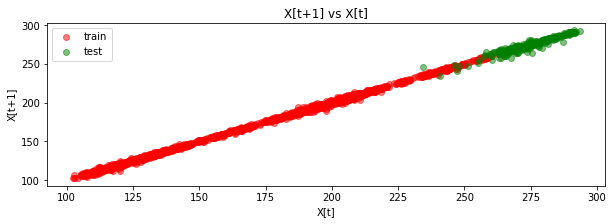

In [26]:
plt.figure(figsize=(10,3))
plt.xlabel("X[t]")
plt.ylabel("X[t+1]")
plt.title("X[t+1] vs X[t]")
plt.scatter(Xtrain[:,0],Xtrain[:,1],c='r',alpha=.5,label='train')
plt.scatter(Xtest[:,0],Xtest[:,1],c='g',alpha=.5,label='test')
plt.legend();

Time Series Forcasting

In [4]:
df=pd.read_csv('airline_passengers.csv',index_col='Month',parse_dates=True)

In [5]:
df['LogPassengers']=np.log(df['Passengers'])

In [6]:
Ntest=12
train=df.iloc[:-Ntest]
test=df.iloc[-Ntest:]

In [7]:
series=df['LogPassengers'].to_numpy()
T=10
X=[]
Y=[]
for t in range(len(series)-T):
    x=series[t:t+T]
    X.append(x)
    y=series[t+T]
    Y.append(y)

In [8]:
X=np.array(X).reshape(-1,T)
Y=np.array(Y)
N=len(X)
print("X.shape",X.shape,"Y.shape",Y.shape)

X.shape (134, 10) Y.shape (134,)


In [9]:
Xtrain,Ytrain=X[:-Ntest],Y[:-Ntest]
Xtest,Ytest=X[-Ntest:],Y[-Ntest:]

In [10]:
lr=LinearRegression()
lr.fit(Xtrain,Ytrain)
lr.score(Xtrain,Ytrain)

0.9599443783339898

In [11]:
lr.score(Xtest,Ytest)

0.6910953044565606

In [12]:
train_idx= df.index <= train.index[-1]
test_idx = ~train_idx

In [75]:
train_idx[:T]=False

In [76]:
df.loc[train_idx,'LR_1step_train']=lr.predict(Xtrain)
df.loc[test_idx,'LR_1step_test']=lr.predict(Xtest)

<AxesSubplot:xlabel='Month'>

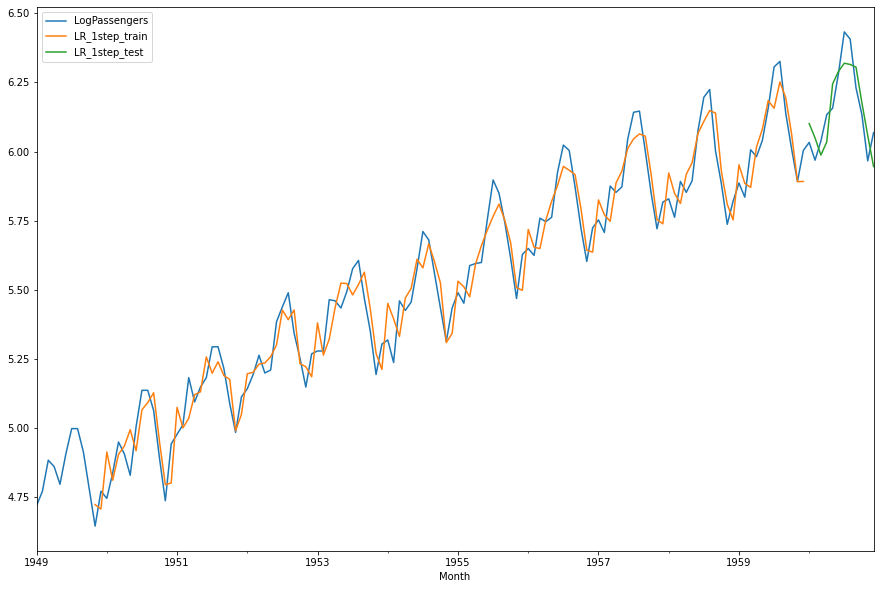

In [77]:
df[['LogPassengers','LR_1step_train','LR_1step_test']].plot(figsize=(15,10))

In [86]:
multistep_prediction=[]
last_x=Xtest[0]

while len(multistep_prediction) < Ntest:
    p=lr.predict(last_x.reshape(1,-1))[0]
    
    multistep_prediction.append(p)
    last_x=np.roll(last_x,-1)
    last_x[-1]=p

In [87]:
df.loc[test_idx,'LR_multistep']=multistep_prediction

<AxesSubplot:xlabel='Month'>

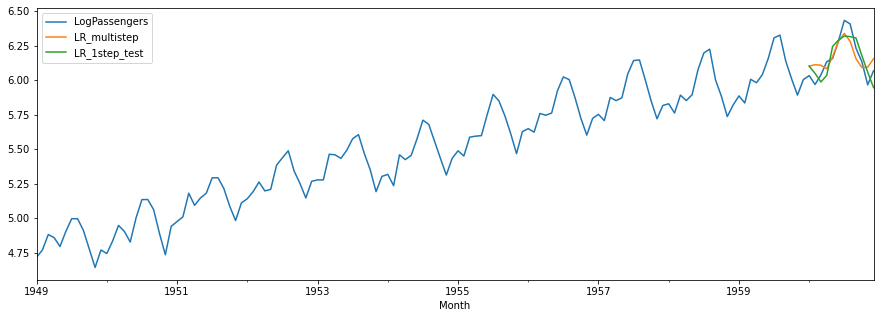

In [88]:
df[['LogPassengers','LR_multistep','LR_1step_test']].plot(figsize=(15,5))

In [89]:
#make multi_ouptup supervised dataset

Tx=T
Ty=Ntest
X=[]
Y=[]
for t in range(len(series)-Tx-Ty+1):
    x=series[t:t+Tx]
    X.append(x)
    y=series[t+Tx:t+Tx+Ty]
    Y.append(y)
 

In [97]:
   
X=np.array(X).reshape(-1,Tx)
Y=np.array(Y).reshape(-1,Ty)   
N=len(X) 
print('X.shape',X.shape,'Y.shap',Y.shape)

X.shape (123, 10) Y.shap (123, 12)


In [101]:
Xtrain_m,Ytrain_m=X[:-1],Y[:-1]
Xtest_m,Ytest_m=X[-1:],Y[-1:]

In [105]:
lr=LinearRegression()
lr.fit(Xtrain_m,Ytrain_m)
lr.score(Xtrain_m,Ytrain_m)

0.9734607773512526

In [114]:
lr.score(Xtest_m,Ytest_m)

c:\Users\4623\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_regression.py:796: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


nan

In [115]:
r2_score(lr.predict(Xtest_m).flatten(),Ytest_m.flatten())

0.8018749676715241

In [118]:
df.loc[test_idx,'LR_multioutput']=lr.predict(Xtest_m).flatten()

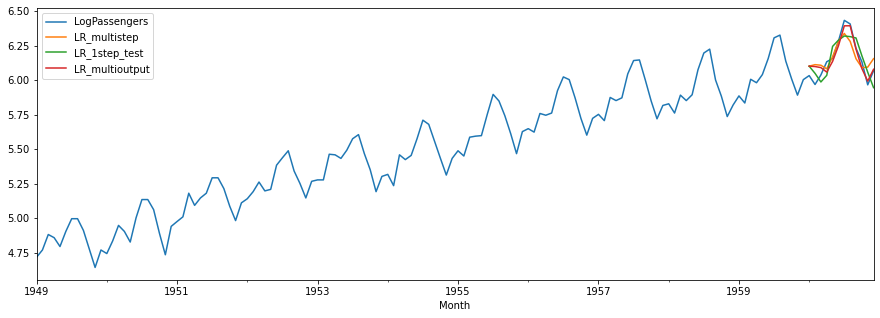

In [119]:
cols=['LogPassengers','LR_multistep','LR_1step_test','LR_multioutput']
df[cols].plot(figsize=(15,5));

In [120]:
mapel=mean_absolute_percentage_error(Ytest,multistep_prediction)
print('multi_step MAPE:',mapel)
mape2=mean_absolute_percentage_error(
    Ytest,df.loc[test_idx,'LR_multioutput']
)
print('multi-output MAPE:',mape2)

multi_step MAPE: 0.012229325023475306
multi-output MAPE: 0.007178924475039743


In [121]:
#Test Other Models

In [122]:
def one_step_and_multistep_forcast(model,name):
    model.fit(Xtrain,Ytrain)
    print('one-step forcast:',name)
    df.loc[train_idx,f'{name}_1step_train']=model.predict(Xtrain)
    df.loc[test_idx,f'{name}_1step_test']=model.predict(Xtest)
    
    multistep_prediction=[]
    last_x=Xtest[0]
    
    while len(multistep_prediction)<Ntest:
        p=model.predict(last_x.reshape(1,-1))[0]
        
        multistep_prediction.append(p)
        
        last_x=np.roll(last_x,-1)
        last_x[-1]=p
        
    df.loc[test_idx,f'{name}_multistep_test']=multistep_prediction
    
    mape=mean_absolute_percentage_error(Ytest,multistep_prediction)
    
    print('Test MAPE (multi-step):',mape)
    
    cols=['LogPassengers',
          f'{name}_1step_train',
          f'{name}_1step_test',
          f'{name}_multistep_test']
    df[cols].plot(figsize=(15,5))
        
    

In [13]:
one_step_and_multistep_forcast(SVR(),'SVR')

NameError: name 'one_step_and_multistep_forcast' is not defined

one-step forcast: RF
Test MAPE (multi-step): 0.02161025768169671


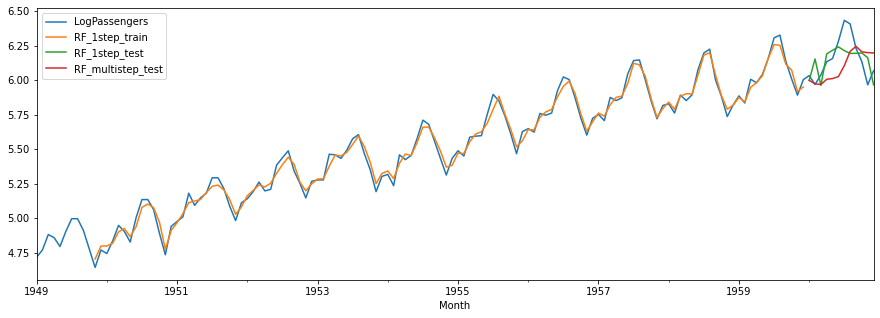

In [124]:
one_step_and_multistep_forcast(RandomForestRegressor(),'RF')

In [125]:
def multi_output_forecast(model,name):
    model.fit(Xtrain_m,Ytrain_m)
    
    df.loc[test_idx,f'{name}_multioutput']=model.predict(Xtest_m).flatten()
    
    mape=mean_absolute_percentage_error(
        Ytest,df.loc[test_idx,f'{name}_multioutput']
    )
    
    cols=['LogPassengers',
          f'{name}_1step_train',
          f'{name}_1step_test',
          f'{name}_multistep_test']
    df[cols].plot(figsize=(15,5))

In [126]:
multi_output_forecast(SVR(),'SVR')

ValueError: y should be a 1d array, got an array of shape (122, 12) instead.

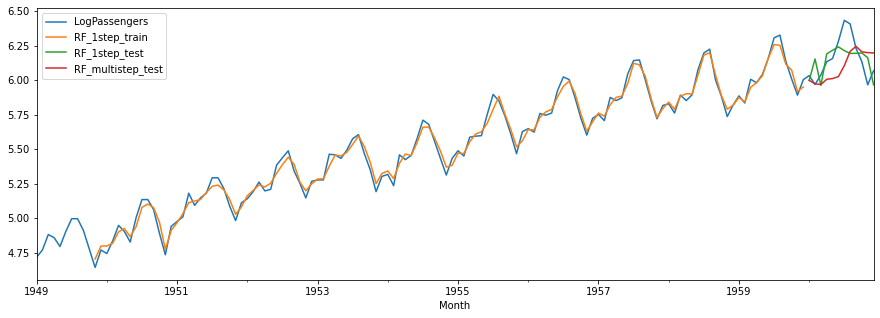

In [127]:
multi_output_forecast(RandomForestRegressor(),'RF')

Airline Passengers

In [10]:
df['LogPassengers']=np.log(df['Passengers'])

In [11]:
df['DiffLogPassengers']=df['LogPassengers'].diff()

In [12]:
Ntest=12
train=df.iloc[:-Ntest]
test=df.iloc[-Ntest:]

In [13]:
series=df['DiffLogPassengers'].to_numpy()[1:]

T=10
X=[]
Y=[]
for t in range(len(series)-T):
    x=series[t:t+T]
    X.append(x)
    y=series[t+T]
    Y.append(y)
    

In [14]:
X=np.array(X).reshape(-1,T)
Y=np.array(Y)
N=len(X)
print('X.shape',X.shape,'Y.shape',Y.shape)

X.shape (133, 10) Y.shape (133,)


In [15]:
Xtrain,Ytrain=X[:-Ntest],Y[:-Ntest]
Xtest,Ytest=X[-Ntest:],Y[-Ntest:]

In [16]:
lr=LinearRegression()
lr.fit(Xtrain,Ytrain)
lr.score(Xtrain,Ytrain)

0.6837135048453121

In [17]:
lr.score(Xtest,Ytest)

0.6492870172668168

In [18]:
train_idx=df.index <=train.index[-1]
test_idx = ~train_idx

In [19]:
train_idx[:T+1] =False

In [22]:
df['ShiftLogPassengers']=df['LogPassengers'].shift(1)
prev=df['ShiftLogPassengers']

In [23]:
last_train=train.iloc[-1]['LogPassengers']

In [27]:
df.loc[train_idx,'LR_1step_train']=prev[train_idx]+lr.predict(Xtrain)
df.loc[test_idx,'LR_1step_test']=prev[test_idx]+lr.predict(Xtest)

<AxesSubplot:xlabel='Month'>

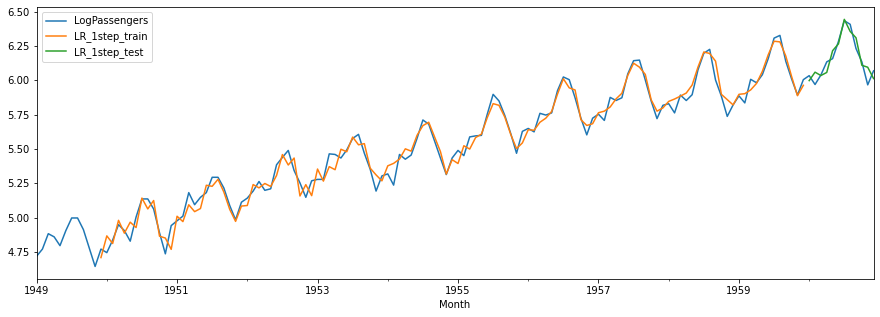

In [28]:
df[['LogPassengers','LR_1step_train','LR_1step_test']].plot(figsize=(15,5))

In [29]:
multistep_prediction=[]

last_x=Xtest[0]
while len(multistep_prediction)<Ntest:
    p=lr.predict(last_x.reshape(1,-1))[0]
    
    multistep_prediction.append(p)
    
    last_x=np.roll(last_x,-1)
    last_x[-1]=p

In [30]:
df.loc[test_idx,'LR_multistep']=last_train+np.cumsum(multistep_prediction)

<AxesSubplot:xlabel='Month'>

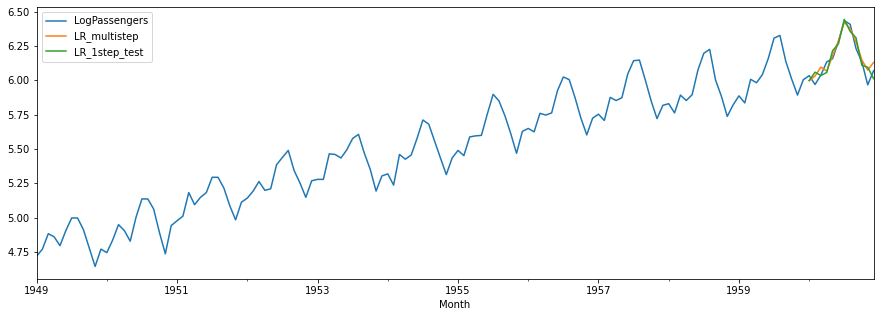

In [32]:
df[['LogPassengers','LR_multistep','LR_1step_test']].plot(figsize=(15,5))

In [59]:
#multi output
Tx=T
Ty=Ntest
X=[]
Y=[]
for t in range(len(series)-Tx-Ty+1):
    x=series[t:t+Tx]
    X.append(x)
    y=series[t+Tx:t+Tx+Ty]
    Y.append(y)
    
X=np.array(X).reshape(-1,Tx)
Y=np.array(Y).reshape(-1,Ty)
N=len(X)
print('Shape.X',X.shape,'Sharp.y',Y.shape)

Shape.X (122, 10) Sharp.y (122, 12)


In [60]:
Xtrain_m,Ytrain_m=X[:-1],Y[:-1]
Xtest_m,Ytest_m=X[-1:],Y[-1:]

In [61]:
lr=LinearRegression()
lr.fit(Xtrain_m,Ytrain_m)
lr.score(Xtrain_m,Ytrain_m)

0.8141637147930583

In [63]:
r2_score(lr.predict(Xtest_m).flatten(),Ytest_m.flatten())

0.7690077978619654

In [65]:
df.loc[test_idx,'LR_multioupt']=last_train+\
    np.cumsum(lr.predict(Xtest_m).flatten())

<AxesSubplot:xlabel='Month'>

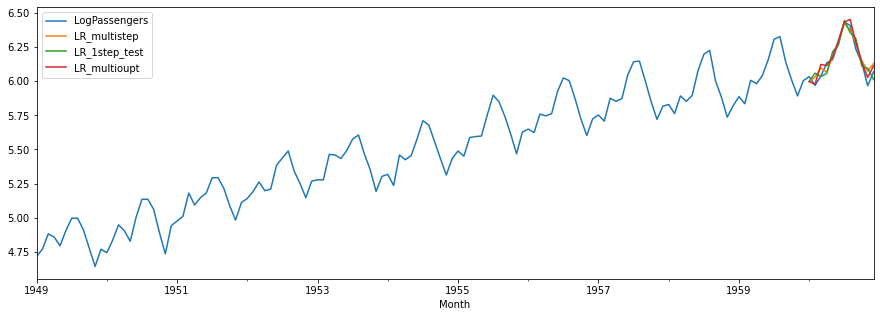

In [69]:
cols=['LogPassengers','LR_multistep','LR_1step_test','LR_multioupt']
df[cols].plot(figsize=(15,5))

In [71]:
#MAPE
test_log_pass=df.iloc[-Ntest:]['LogPassengers']
mapel=mean_absolute_percentage_error(test_log_pass,df.loc[test_idx,'LR_multistep'])
print('multi-step MAPE:',mapel)
mape2=mean_absolute_percentage_error(test_log_pass,df.loc[test_idx,'LR_multioupt'])
print('multi-output MAPE',mape2)

multi-step MAPE: 0.007109281288502526
multi-output MAPE 0.005245261617574892


In [74]:
def one_step_and_multistep_forecast(model,name):
    model.fit(Xtrain,Ytrain)
    print('one_step forecast:',name)
    
    df.loc[train_idx,f'{name}_1step_train']=\
        prev[train_idx]+ model.predict(Xtrain)
    df.loc[test_idx,f'{name}_1step_test']=\
        prev[test_idx]+model.predict(Xtest)
        
    multistep_prediction=[]
    last_x=Xtest[0]
    while len(multistep_prediction)<Ntest:
        p=model.predict(last_x.reshape(1,-1))[0]
        
        multistep_prediction.append(p)
        
        last_x=np.roll(last_x,-1)
        last_x[-1]=p
    df.loc[test_idx,f'{name}_multistep_test']=\
        last_train + np.cumsum(multistep_prediction)
        
    mape=mean_absolute_percentage_error(test_log_pass,df.loc[test_idx,f'{name}_multistep_test'])
    print('Test MAPE (multi-step)',mape)
    
    cols=['LogPassengers',f'{name}_1step_train',
    f'{name}_1step_test',
    f'{name}_multistep_test']
    df[cols].plot(figsize=(15,5))


one_step forecast: SVR
Test MAPE (multi-step) 0.012149122102392764


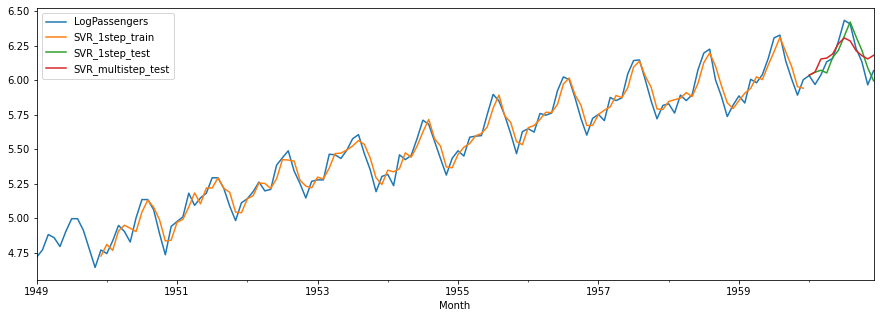

In [75]:
one_step_and_multistep_forecast(SVR(),'SVR')

one_step forecast: RF
Test MAPE (multi-step) 0.005766428410620683


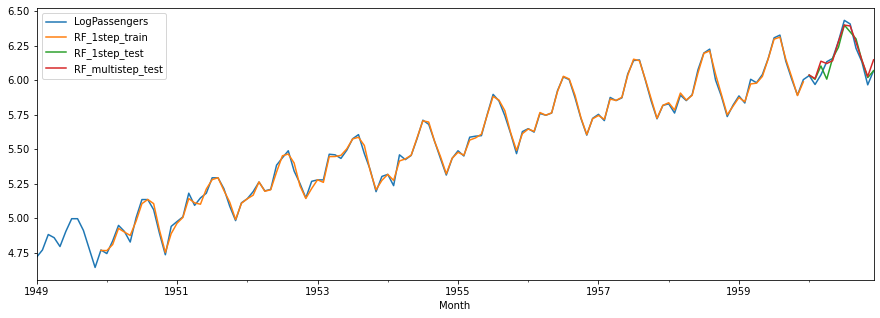

In [77]:
one_step_and_multistep_forecast(RandomForestRegressor(),'RF')

In [87]:
def multi_output_forecast(model,name):
    model.fit(Xtrain_m,Ytrain_m)
    df.loc[test_idx,f'{name}_multioutput']=\
        last_train+ np.cumsum(model.predict(Xtest_m).flatten())
    mape=mean_absolute_percentage_error(
        test_log_pass,df.loc[test_idx,f'{name}_multioutput']
    )
    print('Test MAPE (multi-output)',mape)
    cols=['LogPassengers',f'{name}_1step_train',
    f'{name}_1step_test',
    f'{name}_multistep_test',
    f'{name}_multioutput']
    df[cols].plot(figsize=(15,5))

In [96]:
class SVRWrapper:
    def __init__(self ,h,**args):
        self.h=h
        self.models=[SVR(**args) for _ in range(h)]
    def fit(self,X,Y):
        for k in range(self.h):
            self.models[k].fit(X,Y[:,k])
    def predict (self,X):
        P=[m.predict(X) for m in self.models]
        return np.hstack(p)

In [97]:
multi_output_forecast(SVRWrapper(Ntest),'SVR')

TypeError: dispatcher for __array_function__ did not return an iterable

Test MAPE (multi-output) 0.0048833174247764405


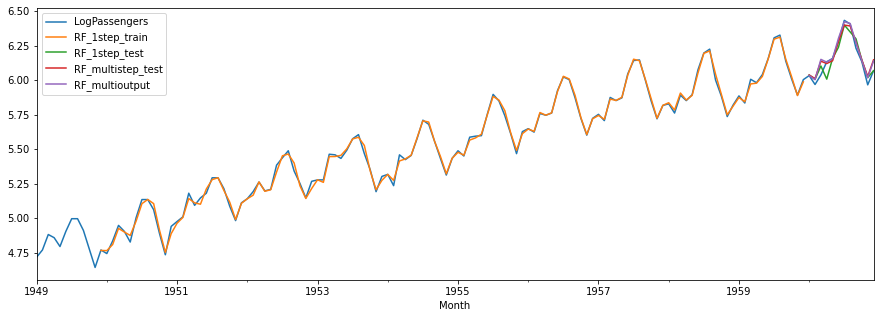

In [89]:
multi_output_forecast(RandomForestRegressor(),'RF')

Stock Price

In [4]:
df0=pd.read_csv('sp500sub.csv',index_col='Date',parse_dates=True)

In [5]:
df0.head()

,Open,High,Low,Close,Adj Close,Volume,Name
Date,,,,,,,
2010-01-04,9.22,9.51,9.17,9.50,9.50,1865400.0,INCY
2010-01-05,9.51,10.29,9.45,10.27,10.27,7608900.0,INCY
2010-01-06,10.38,11.09,10.35,11.00,11.00,8046700.0,INCY
2010-01-07,11.00,11.06,10.62,10.82,10.82,3680300.0,INCY
2010-01-08,10.82,11.00,10.75,10.94,10.94,1529300.0,INCY


In [6]:
df=df0[df0['Name']=="IBM"][['Close']].copy()

In [7]:
df['LogClose']=np.log(df['Close'])

In [7]:
df['DiffLogClose']=df['LogClose'].diff()

In [8]:
Ntest=12
train=df.iloc[:-Ntest]
test=df.iloc[-Ntest:]

In [9]:
series=df['DiffLogClose'].to_numpy()[1:]

In [10]:
#1step train
T=12
X=[]
Y=[]

for t in range(len(series)-T):
    x=series[t:t+T]
    X.append(x)
    
    y=series[t+T]
    Y.append(y)
    
X=np.array(X).reshape(-1,T)
Y=np.array(Y)
N=len(X)

print('shape.X',X.shape,'shape.Y',Y.shape)

shape.X (2250, 12) shape.Y (2250,)


In [12]:
Xtrain,Ytrain=X[:-Ntest],Y[:-Ntest]
Xtest,Ytest=X[-Ntest:],Y[-Ntest:]

In [13]:
lr=LinearRegression()
lr.fit(Xtrain,Ytrain)
lr.score(Xtrain,Ytrain)

0.0055114641154655475

In [14]:
lr.score(Xtest,Ytest)

-0.08823436646150373

In [15]:
train_idx= df.index <= train.index[-1]
test_idx=~ train_idx

train_idx[:T+1]=False

In [18]:
df['ShiftLogClose']=df['LogClose'].shift(1)
prev=df['ShiftLogClose']


In [19]:
last_train=train.iloc[-1]['LogClose']

In [26]:
df.loc[train_idx,'LR_1step_train']=prev[train_idx]+lr.predict(Xtrain)

df.loc[test_idx,'LR_1step_test']=prev[test_idx]+lr.predict(Xtest)

<AxesSubplot:xlabel='Date'>

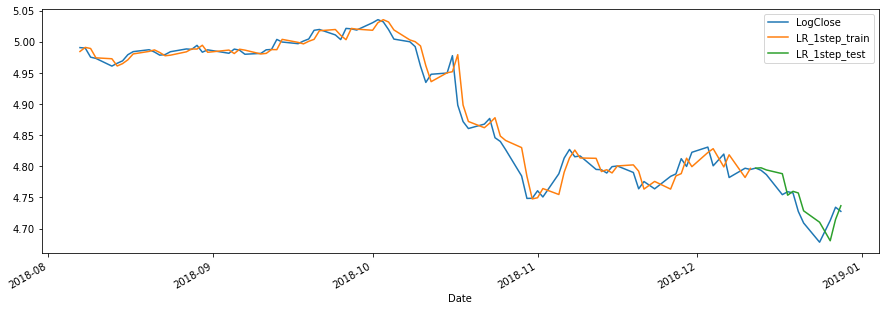

In [27]:
cols=['LogClose','LR_1step_train','LR_1step_test']
df.iloc[-100:][cols].plot(figsize=(15,5))

In [31]:
#multistep forecast
multistep_prediction=[]
last_x=Xtest[0]

while len(multistep_prediction)<Ntest:
    p=lr.predict(last_x.reshape(1,-1))[0]
    
    multistep_prediction.append(p)
    
    last_x=np.roll(last_x,-1)
    last_x[-1]=p

In [32]:
df.loc[test_idx,'LR_multistep']=last_train+np.cumsum(multistep_prediction)

<AxesSubplot:xlabel='Date'>

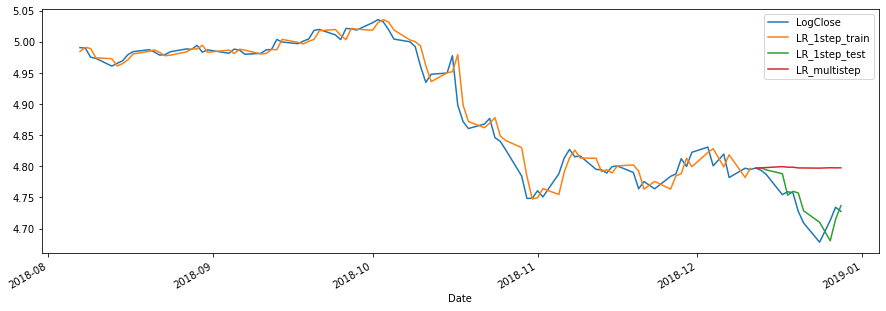

In [33]:
cols=['LogClose','LR_1step_train','LR_1step_test','LR_multistep']
df.iloc[-100:][cols].plot(figsize=(15,5))

In [34]:
#multi output
Tx=T
Ty=Ntest

X=[]
Y=[]

for t in range(len(series)-Tx-Ty+1):
    x=series[t:t+Tx]
    X.append(x)
    
    y=series[t+Tx:t+Tx+Ty]
    Y.append(y)
    
X=np.array(X).reshape(-1,Tx)
Y=np.array(Y).reshape(-1,Ty)
N=len(X)
print('shape.X',X.shape,'shape.Y',Y.shape)


shape.X (2239, 12) shape.Y (2239, 12)


In [52]:
Xtrain_m,Ytrain_m=X[:-1],Y[:-1]
Xtest_m,Ytst_m=X[-1:],Y[-1:]

In [53]:
lr=LinearRegression()
lr.fit(Xtrain_m,Ytrain_m)
lr.score(Xtrain_m,Ytrain_m)

0.005128313388965596

In [54]:
r2_score(lr.predict(Xtest_m).flatten(),Ytst_m.flatten())

-473.0963674858714

In [56]:
df.loc[test_idx,'LR_multioutput']=last_train+np.cumsum(lr.predict(Xtest_m).flatten())

<AxesSubplot:xlabel='Date'>

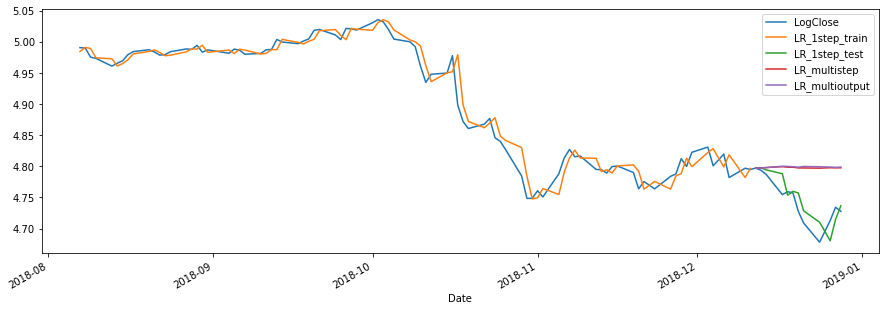

In [57]:
cols=['LogClose','LR_1step_train','LR_1step_test','LR_multistep','LR_multioutput']
df.iloc[-100:][cols].plot(figsize=(15,5))

In [58]:
#MAPE

test_log_pass=df.iloc[-Ntest:]['LogClose']
mape1=mean_absolute_percentage_error(test_log_pass,df.loc[test_idx,'LR_multistep'])
print('multi-step mape',mape1)
mape2=mean_absolute_percentage_error(test_log_pass,df.loc[test_idx,'LR_multioutput'])
print('multi-output mape',mape2)

multi-step mape 0.01121888378069776
multi-output mape 0.011418709227427326


In [61]:
#test_othe models
def one_step_and_multistep_forecast(model,name):
    model.fit(Xtrain,Ytrain)
    print('one_step forecast:',name)
    
    df.loc[train_idx,f'{name}_1step_train']=\
        prev[train_idx]+ model.predict(Xtrain)
    df.loc[test_idx,f'{name}_1step_test']=\
        prev[test_idx]+model.predict(Xtest)
        
    multistep_prediction=[]
    last_x=Xtest[0]
    while len(multistep_prediction)<Ntest:
        p=model.predict(last_x.reshape(1,-1))[0]
        
        multistep_prediction.append(p)
        
        last_x=np.roll(last_x,-1)
        last_x[-1]=p
    df.loc[test_idx,f'{name}_multistep_test']=\
        last_train + np.cumsum(multistep_prediction)
        
    mape=mean_absolute_percentage_error(test_log_pass,df.loc[test_idx,f'{name}_multistep_test'])
    print('Test MAPE (multi-step)',mape)
    
    cols=['LogClose',f'{name}_1step_train',
    f'{name}_1step_test',
    f'{name}_multistep_test']
    df.iloc[-100:][cols].plot(figsize=(15,5))


one_step forecast: SVR
Test MAPE (multi-step) 0.009692971150318395


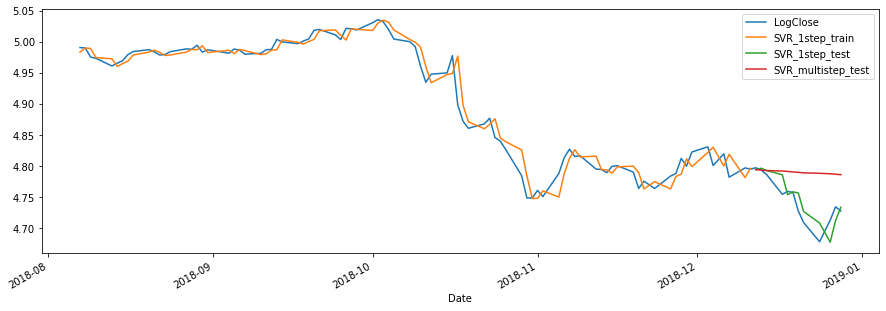

In [62]:
one_step_and_multistep_forecast(SVR(),'SVR')

one_step forecast: FR
Test MAPE (multi-step) 0.012178186992450867


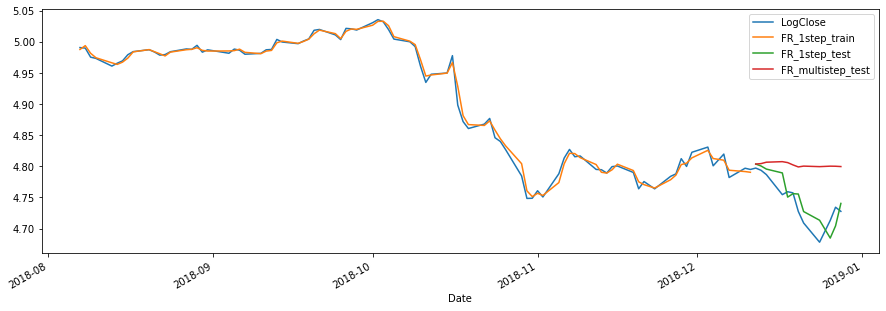

In [63]:
one_step_and_multistep_forecast(RandomForestRegressor(),'FR')

In [66]:
def multi_output_forecast(model,name):
    model.fit(Xtrain_m,Ytrain_m)
    df.loc[test_idx,f'{name}_multioutput']=\
        last_train+ np.cumsum(model.predict(Xtest_m).flatten())
    mape=mean_absolute_percentage_error(
        test_log_pass,df.loc[test_idx,f'{name}_multioutput']
    )
    print('Test MAPE (multi-output)',mape)
    cols=['LogClose',f'{name}_1step_train',
    f'{name}_1step_test',
    f'{name}_multistep_test',
    f'{name}_multioutput']
    df.iloc[-100:][cols].plot(figsize=(15,5))

Test MAPE (multi-output) 0.010246377855820825


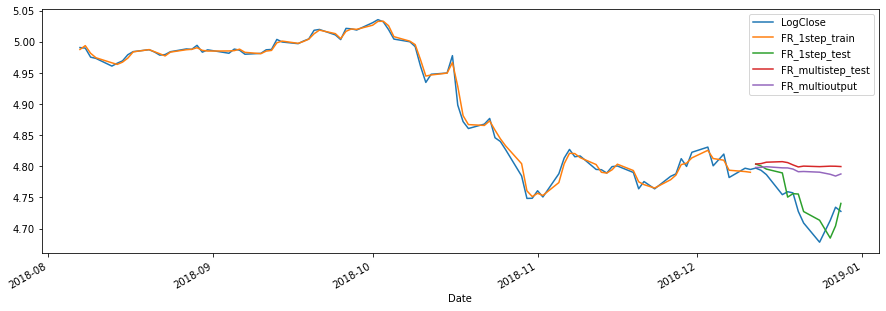

In [67]:
multi_output_forecast(RandomForestRegressor(),'FR')

Directoin prediction

In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

In [26]:
df['LogReturn']=df['LogClose'].diff()

In [10]:
series=df['LogReturn'].to_numpy()[1:]
target=(series>0)*1

In [11]:
#1step train
T=21
X=[]
Y=[]

for t in range(len(series)-T):
    x=series[t:t+T]
    X.append(x)
    
    y=target[t+T]
    Y.append(y)
    
X=np.array(X).reshape(-1,T)
Y=np.array(Y)
N=len(X)

print('shape.X',X.shape,'shape.Y',Y.shape)

shape.X (2241, 21) shape.Y (2241,)


In [27]:
Ntest=252
train=df.iloc[:-Ntest]
test=df.iloc[-Ntest:]

In [28]:
Xtrain,Ytrain=X[:-Ntest],Y[:-Ntest]
Xtest,Ytest=X[-Ntest:],Y[-Ntest:]

In [32]:
lr=LogisticRegression()
lr.fit(Xtrain,Ytrain)
lr.score(Xtrain,Ytrain)

0.5093011563599799

In [33]:
lr.score(Xtest,Ytest)

0.49603174603174605

In [34]:
svc=SVC()
svc.fit(Xtrain,Ytrain)
svc.score(Xtrain,Ytrain)

0.7551533433886375

In [35]:
svc.score(Xtest,Ytest)

0.49603174603174605

In [36]:
rf=RandomForestClassifier()
rf.fit(Xtrain,Ytrain)
rf.score(Xtrain,Ytrain)

1.0

In [37]:
rf.score(Xtest,Ytest)

0.49603174603174605